Aap sab ko *Classification Assignment* diya ja raha hai. Is assignment ka objective data preprocessing aur classification model develop karna hai.

### Assignment Requirements

* Dataset ko properly analyze karein.
* Missing values ko handle karein (agar available hon).
* Required encoding perform karein (agar zarurat ho).
* Feature Scaling apply karein (agar required ho).
* Agar dataset imbalanced ho to usay Balanced Dataset mein convert karein.
* Different Classification Models apply karein aur unki performance compare karein.
* Accuracy, Precision, Recall, F1-Score, Classification Report aur Confusion Matrix generate karein.
* Best performing model select karein.
* Hyperparameter Tuning karke model ki performance improve karein.
* Model ki accuracy ko maximum possible level tak optimize karne ki koshish karein.
* Har step ki proper explanation aur code comments bhi include karein.

### Dataset: framingham.csv (Heart Disease - 10 Year CHD Risk)

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# Basic info - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
# Summary statistics
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [5]:
# Check for missing values
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Several columns have missing values. Since all of them are numeric, we fill the missing values with the median of each column (median is used instead of mean because it is less affected by outliers).

In [6]:
# Fill missing values with median for each column that has missing values
df['education'] = df['education'].fillna(df['education'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].median())
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())
df['glucose'] = df['glucose'].fillna(df['glucose'].median())

df.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Encoding
All the columns in this dataset are already numeric (0/1 flags or numbers), so no encoding is required here.

### EDA - Target Variable (TenYearCHD)

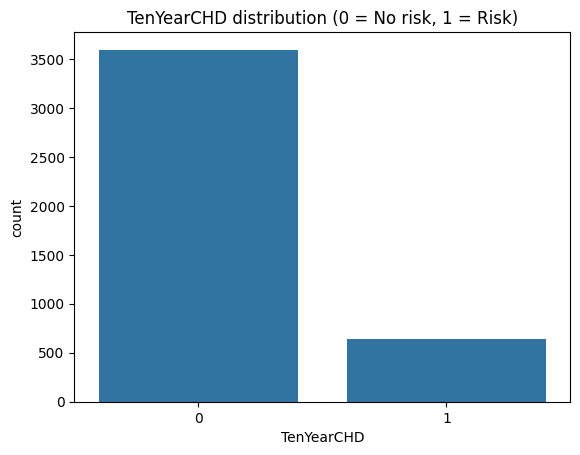

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [8]:
sns.countplot(x='TenYearCHD', data=df)
plt.title('TenYearCHD distribution (0 = No risk, 1 = Risk)')
plt.show()

df['TenYearCHD'].value_counts()

The target is clearly imbalanced - a lot more people with 0 (no risk) than 1 (risk). This will be handled later using SMOTE before training the models.

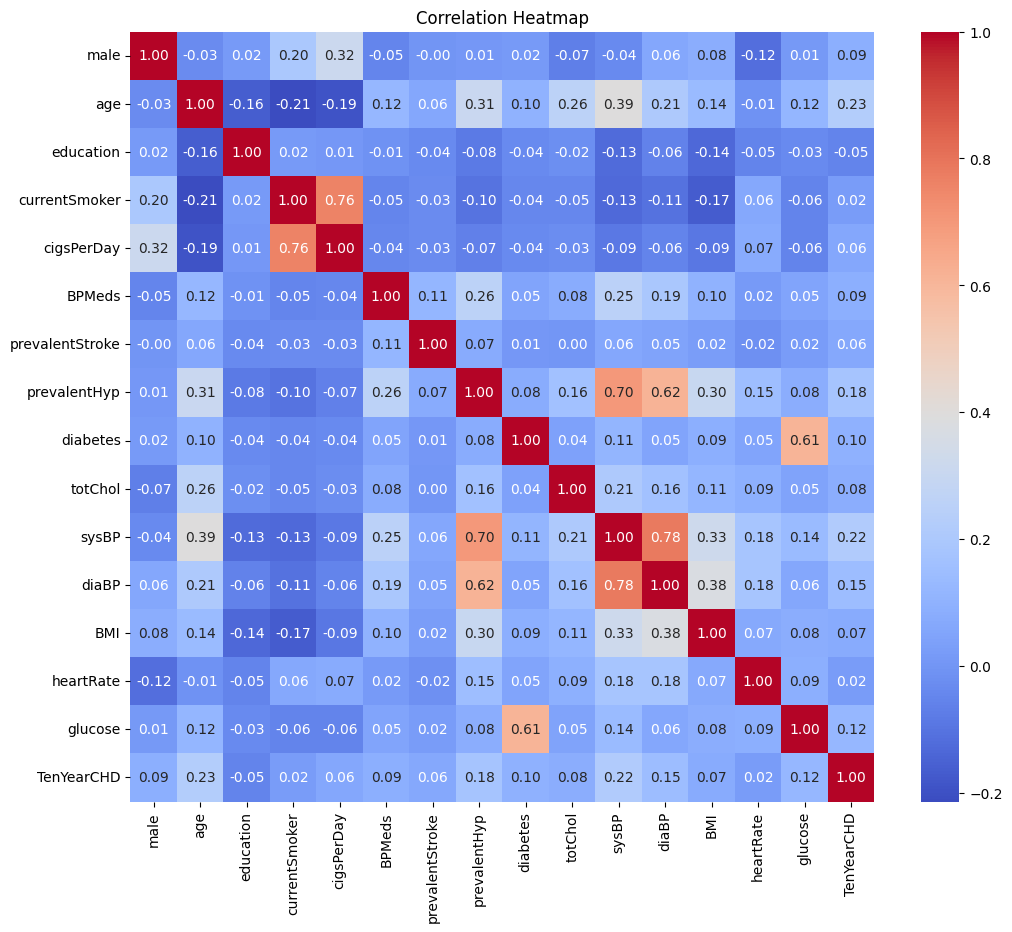

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Feature and Target Selection

In [10]:
# Target: what we are predicting
y = df['TenYearCHD']

# Features: everything else
X = df.drop(columns=['TenYearCHD'])

print(X.shape, y.shape)

(4238, 15) (4238,)


### Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((3390, 15), (848, 15))

### Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Handling Imbalanced Dataset
Since TenYearCHD is imbalanced, SMOTE (Synthetic Minority Oversampling Technique) is used to balance the training data. This is only applied to the training set, not the test set, so we evaluate on real, untouched data.

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 2875, 1: 515}
After SMOTE: {0: 2875, 1: 2875}


### Train Multiple Classification Models and Compare

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Dictionary of models we want to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f'{name} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

Logistic Regression -> Accuracy: 0.6639, Precision: 0.2484, Recall: 0.5969, F1: 0.3508
Decision Tree -> Accuracy: 0.7252, Precision: 0.2143, Recall: 0.3023, F1: 0.2508


Random Forest -> Accuracy: 0.7913, Precision: 0.2391, Recall: 0.1705, F1: 0.1991
KNN -> Accuracy: 0.6427, Precision: 0.2119, Recall: 0.4961, F1: 0.2970


In [15]:
# Put results in a table, sorted by F1 score (a good balance of precision and recall)
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797
3,KNN,0.642689,0.211921,0.496124,0.296984
1,Decision Tree,0.725236,0.214286,0.302326,0.250804
2,Random Forest,0.791274,0.239130,0.170543,0.199095


### Best Model - Detailed Report

In [16]:
# Random Forest is picked as the best performer based on the comparison table above
best_model_initial = RandomForestClassifier(random_state=42)
best_model_initial.fit(X_train_balanced, y_train_balanced)
y_pred_rf = best_model_initial.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       719
           1       0.24      0.17      0.20       129

    accuracy                           0.79       848
   macro avg       0.55      0.54      0.54       848
weighted avg       0.76      0.79      0.78       848



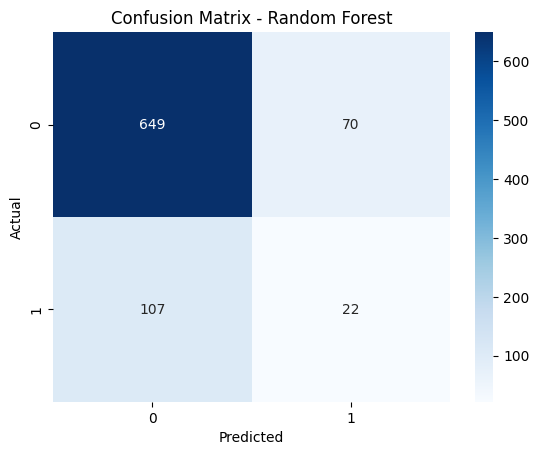

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Hyperparameter Tuning (Random Forest)

In [18]:
from sklearn.model_selection import GridSearchCV

# A small grid of values to try, keeping it simple
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print('Best parameters:', grid_search.best_params_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [19]:
# Evaluate the tuned model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f'Tuned Random Forest -> Accuracy: {acc_best:.4f}, Precision: {prec_best:.4f}, Recall: {rec_best:.4f}, F1: {f1_best:.4f}')
print()
print(classification_report(y_test, y_pred_best))

Tuned Random Forest -> Accuracy: 0.8007, Precision: 0.2619, Recall: 0.1705, F1: 0.2066

              precision    recall  f1-score   support

           0       0.86      0.91      0.89       719
           1       0.26      0.17      0.21       129

    accuracy                           0.80       848
   macro avg       0.56      0.54      0.55       848
weighted avg       0.77      0.80      0.78       848



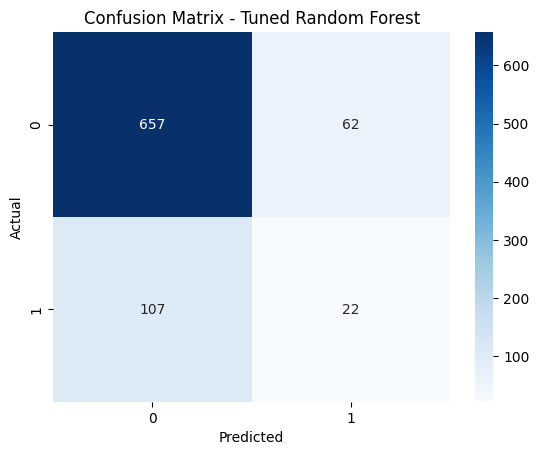

In [20]:
# Confusion Matrix for the tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()